In [ ]:
"""
==================================================
ML LEARNING JOURNEY - DAY 71
==================================================

Week: 11 of 24
Day: 71 of 168
Date: Monday, January 20, 2026
Topic: Policy Gradients & REINFORCE Algorithm


Week 11 Progress:
🔄 Day 71: Policy Gradients & REINFORCE (TODAY!)
⬜ Day 72: REINFORCE Training & Optimization
⬜ Day 73: Actor-Critic (A2C/A3C)
⬜ Day 74: A2C Training & Analysis
⬜ Day 75: PPO (Proximal Policy Optimization)
⬜ Day 76: PPO Training & Optimization
⬜ Day 77: Algorithm Comparison & Week Completion

Progress: 14.3% (1/7 days)

==================================================
🎯 Week 11: Policy Gradient Methods & Advanced RL

NEW PARADIGM: Moving from Value-Based to Policy-Based RL!

Week 10 Recap:
✅ Value-based methods (DQN family)
   - Learn Q(s,a) → derive policy
   - Discrete actions
   - Off-policy learning

Week 11 Focus:
🆕 Policy-based methods
   - Learn π(a|s) directly
   - Works with continuous actions
   - On-policy learning
   - Different optimization approach

==================================================
🎯 Today's Learning Objectives:

1. Policy Gradient Fundamentals
   - What is a policy?
   - Parameterized policies (neural networks)
   - Why learn policies directly?
   - Advantages over value-based methods

2. Policy Gradient Theorem
   - Objective function (expected return)
   - Gradient of expected return
   - REINFORCE derivation
   - Mathematical foundations

3. REINFORCE Algorithm
   - Monte Carlo policy gradient
   - Episode-based updates
   - Gradient estimation
   - Baseline methods (variance reduction)

4. Implementation
   - Policy network architecture
   - Trajectory collection
   - Gradient computation
   - Training loop

5. Comparison with DQN
   - When to use policy gradients?
   - Advantages and disadvantages
   - Continuous vs discrete actions
   - Sample efficiency

📚 Today's Structure:
Part 1 (2h): Policy Gradient Theory
Part 2 (2h): REINFORCE Algorithm Deep Dive
Part 3 (2h): Implementation (CartPole)
Part 4 (2h): Analysis & Comparison with DQN

Total Time: ~8 hours

🎯 SUCCESS CRITERIA:
✅ Understand policy gradient theorem
✅ Derive REINFORCE algorithm
✅ Implement policy network
✅ Train on CartPole environment
✅ Achieve >150 average reward
✅ Compare with DQN performance
✅ Understand variance issues

💡 Key Insight:
Policy gradients are fundamentally different from DQN!
- DQN: Learn values → act greedily
- Policy Gradients: Learn actions directly

This opens doors to:
- Continuous action spaces (robotics!)
- Stochastic policies
- Natural exploration
- Different optimization landscape

Let's dive into policy-based RL! 🚀

==================================================
"""

In [1]:
# ==================================================
# IMPORT LIBRARIES
# ==================================================

print("=" * 80)
print("📚 IMPORTING LIBRARIES")
print("=" * 80)

# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import deque
import random
import time
import os
from datetime import datetime

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.distributions import Categorical

# Gymnasium (OpenAI Gym)
import gymnasium as gym

print("✅ Libraries imported!")

# Set random seeds for reproducibility
np.random.seed(42)
random.seed(42)
torch.manual_seed(42)

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n🖥️  Using device: {device}")
if device.type == 'cuda':
    print(f"   GPU: {torch.cuda.get_device_name(0)}")

# Matplotlib settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

# Create results directories
os.makedirs('results/reinforce', exist_ok=True)
os.makedirs('results/comparisons', exist_ok=True)
os.makedirs('results/models', exist_ok=True)

print("\n✅ Setup complete!")
print("=" * 80)
print(f"\n📊 PyTorch version: {torch.__version__}")
print(f"📊 NumPy version: {np.__version__}")
print(f"📊 Gymnasium version: {gym.__version__}")
print(f"📊 Random seed: 42")
print("=" * 80)

print("\n🎯 Ready for Day 71 - Policy Gradients!")
print("=" * 80)

📚 IMPORTING LIBRARIES
✅ Libraries imported!

🖥️  Using device: cpu

✅ Setup complete!

📊 PyTorch version: 2.9.1+cpu
📊 NumPy version: 2.3.5
📊 Gymnasium version: 1.2.2
📊 Random seed: 42

🎯 Ready for Day 71 - Policy Gradients!


In [2]:
print("\n" + "=" * 80)
print("📖 PART 1: POLICY GRADIENT FUNDAMENTALS")
print("=" * 80)


📖 PART 1: POLICY GRADIENT FUNDAMENTALS


In [3]:
# ==================================================
# EXERCISE 1.1: POLICY GRADIENT THEORY
# ==================================================

print("\n" + "=" * 80)
print("EXERCISE 1.1: Understanding Policy Gradients")
print("=" * 80)

"""
📖 THEORY: From Value-Based to Policy-Based RL

PARADIGM SHIFT:

Value-Based (DQN - What we did in Week 10):
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. Learn Q(s,a) - value of taking action a in state s
2. Policy is implicit: π(s) = argmax_a Q(s,a)
3. Act greedily based on learned values
4. Works great for discrete actions

Example: CartPole
- Learn Q(left) and Q(right) for each state
- Choose action with higher Q-value
- Policy = greedy selection

Policy-Based (REINFORCE - What we're learning today):
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. Learn π(a|s; θ) - probability of action a given state s
2. Policy is explicit: parameterized by neural network weights θ
3. Sample actions from learned distribution
4. Works with continuous AND discrete actions

Example: CartPole
- Learn P(left) and P(right) for each state
- Sample action from probability distribution
- Policy = stochastic sampling

KEY DIFFERENCES:

┌─────────────────────┬──────────────────────┬──────────────────────┐
│     Aspect          │   Value-Based (DQN)  │  Policy-Based (PG)   │
├─────────────────────┼──────────────────────┼──────────────────────┤
│ What we learn       │ Q(s,a) values        │ π(a|s) policy        │
│ Policy type         │ Deterministic        │ Stochastic           │
│ Action space        │ Discrete only        │ Discrete + Continuous│
│ Action selection    │ argmax Q(s,a)        │ Sample from π(a|s)   │
│ Exploration         │ ε-greedy (external)  │ Built-in (stochastic)│
│ Gradient target     │ Q-values             │ Policy parameters    │
│ Update frequency    │ Every step (off-pol) │ After episode (on-p) │
│ Sample efficiency   │ High (replay buffer) │ Low (fresh samples)  │
│ Convergence         │ Can be unstable      │ More stable          │
│ Local optima        │ Rare                 │ Common               │
└─────────────────────┴──────────────────────┴──────────────────────┘

WHY POLICY GRADIENTS?

Advantages:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. Continuous Actions
   - DQN: Can't handle infinite action spaces
   - PG: Natural for continuous control (robot joints, steering angle)
   
   Example: Self-driving car
   - Steering angle: -30° to +30° (infinite choices!)
   - DQN: Would need to discretize (lose precision)
   - PG: Output mean and std of Gaussian distribution

2. Stochastic Policies
   - Some problems need randomness
   - Rock-Paper-Scissors: deterministic policy loses!
   - PG naturally learns optimal stochastic policy

3. Simpler in Some Cases
   - High-dimensional action spaces
   - Policy might be simpler than value function
   
   Example: Robot with 7 joints
   - Q-function: Q(state, 7D action) - complex!
   - Policy: π(7D action | state) - can be simpler

4. Better Convergence Guarantees
   - Policy gradient: guaranteed to converge to local optimum
   - Q-learning: can diverge (especially with function approximation)

Disadvantages:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. Sample Inefficient
   - Need fresh experiences (on-policy)
   - Can't reuse old data like DQN
   - Slower learning

2. High Variance
   - Monte Carlo estimates are noisy
   - Needs many episodes to average out
   - Variance reduction techniques essential

3. Local Optima
   - Can get stuck in suboptimal policies
   - Gradient descent on policy space has many local minima

4. Sensitive to Hyperparameters
   - Learning rate especially critical
   - Too high: policy collapses
   - Too low: very slow learning

WHEN TO USE EACH?

Use DQN (Value-Based):
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
✓ Discrete action spaces
✓ Sample efficiency matters
✓ Deterministic optimal policy
✓ Can afford experience replay

Examples: Atari games, board games, discrete control

Use Policy Gradients:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
✓ Continuous actions
✓ Stochastic policies needed
✓ High-dimensional action spaces
✓ Simpler policy than value function

Examples: Robotics, continuous control, strategic games

MATHEMATICAL SETUP:

Policy Parameterization:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
π(a|s; θ) - Policy parameterized by neural network weights θ

For discrete actions (like CartPole):
- Network outputs logits for each action
- Apply softmax to get probabilities
- π(a|s; θ) = softmax(neural_net(s; θ))

For continuous actions (like robot control):
- Network outputs mean μ and std σ
- Actions sampled from Gaussian: a ~ N(μ(s;θ), σ(s;θ))

Objective Function:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Goal: Maximize expected return

J(θ) = E_π[R(τ)]

Where:
- τ = (s₀, a₀, r₀, s₁, a₁, r₁, ...) is a trajectory
- R(τ) = Σ γᵗ rₜ is the discounted return
- E_π means expectation over trajectories from policy π

In plain English:
"We want to find policy parameters θ that maximize the expected 
total reward we get when following that policy"

The Challenge:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
How do we optimize J(θ)?
- Can't compute expectation exactly (infinite trajectories!)
- Can't differentiate through environment dynamics
- Need to estimate gradient from sample trajectories

This is where REINFORCE comes in! (Next section)

INTUITION:

Think of it like training a student:

Value-Based (DQN):
- Teach student the value of different choices
- Student picks best choice based on learned values
- Like teaching by explaining consequences

Policy-Based (PG):
- Teach student what to do directly
- Student learns actions themselves
- Like teaching by demonstration and feedback

Both work, but for different situations!

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
"""

print("\n💡 Key Concepts Summary:")
print("=" * 80)

summary = """
POLICY GRADIENT FUNDAMENTALS:

1. PARADIGM SHIFT
   Value-Based → Policy-Based
   Learn Q(s,a) → Learn π(a|s) directly

2. KEY ADVANTAGES
   ✓ Handles continuous actions
   ✓ Natural stochastic policies
   ✓ Better convergence guarantees
   ✓ Simpler in high dimensions

3. KEY DISADVANTAGES
   ✗ Sample inefficient (on-policy)
   ✗ High variance (Monte Carlo)
   ✗ Prone to local optima
   ✗ Hyperparameter sensitive

4. WHEN TO USE
   - Continuous action spaces
   - Stochastic policies needed
   - Robotics and control tasks

5. MATHEMATICAL GOAL
   Maximize: J(θ) = E_π[R(τ)]
   Find: θ* = argmax_θ J(θ)
   
Next: Policy Gradient Theorem & REINFORCE! 🚀
"""

print(summary)

print("\n✅ Exercise 1.1 Complete!")
print("=" * 80)


EXERCISE 1.1: Understanding Policy Gradients

💡 Key Concepts Summary:

POLICY GRADIENT FUNDAMENTALS:

1. PARADIGM SHIFT
   Value-Based → Policy-Based
   Learn Q(s,a) → Learn π(a|s) directly

2. KEY ADVANTAGES
   ✓ Handles continuous actions
   ✓ Natural stochastic policies
   ✓ Better convergence guarantees
   ✓ Simpler in high dimensions

3. KEY DISADVANTAGES
   ✗ Sample inefficient (on-policy)
   ✗ High variance (Monte Carlo)
   ✗ Prone to local optima
   ✗ Hyperparameter sensitive

4. WHEN TO USE
   - Continuous action spaces
   - Stochastic policies needed
   - Robotics and control tasks

5. MATHEMATICAL GOAL
   Maximize: J(θ) = E_π[R(τ)]
   Find: θ* = argmax_θ J(θ)

Next: Policy Gradient Theorem & REINFORCE! 🚀


✅ Exercise 1.1 Complete!



EXERCISE 1.2: Policy Gradient Theorem

💡 Policy Gradient Theorem Summary:

POLICY GRADIENT THEOREM:

GOAL:
  Maximize J(θ) = E_π[R(τ)]

GRADIENT:
  ∇_θ J(θ) = E_π[(Σₜ ∇_θ log π_θ(aₜ|sₜ)) R(τ)]

MONTE CARLO ESTIMATE:
  ∇_θ J(θ) ≈ (1/N) Σᵢ (Σₜ ∇_θ log π_θ(aₜ⁽ⁱ⁾|sₜ⁽ⁱ⁾)) R(τ⁽ⁱ⁾)

INTUITION:
  "Increase probability of actions that led to good outcomes"

KEY PROPERTIES:
  ✓ Model-free (don't need environment dynamics)
  ✓ Works with any differentiable policy
  ✓ Handles continuous and discrete actions
  ✗ High variance (Monte Carlo estimation)
  ✗ Sample inefficient (on-policy)

NEXT: REINFORCE Algorithm (practical implementation)



C:\Users\audrey\AppData\Local\Temp\ipykernel_16756\521928824.py:304: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\audrey\AppData\Local\Temp\ipykernel_16756\521928824.py:305: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  plt.savefig('results/reinforce/policy_gradient_concept.png', dpi=300, bbox_inches='tight')



✅ Visualization saved!


C:\Users\audrey\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


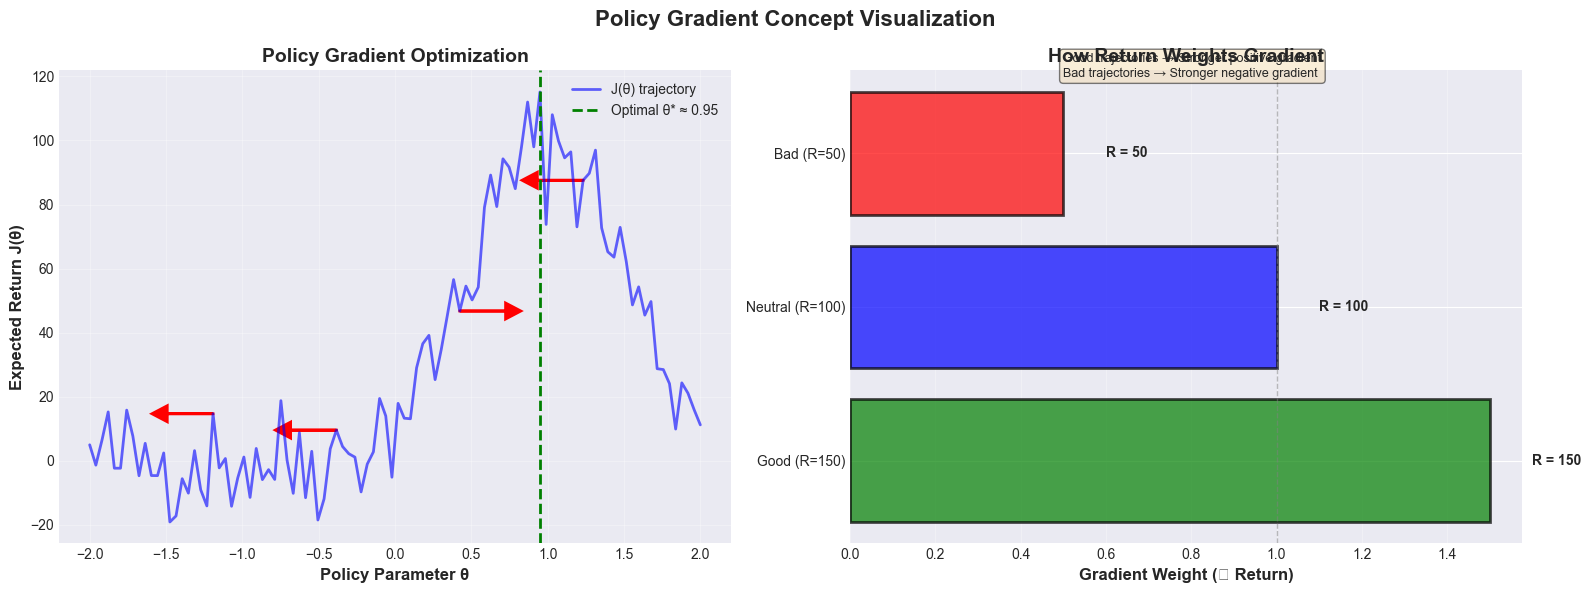


✅ Exercise 1.2 Complete!


In [4]:
# ==================================================
# EXERCISE 1.2: POLICY GRADIENT THEOREM
# ==================================================

print("\n" + "=" * 80)
print("EXERCISE 1.2: Policy Gradient Theorem")
print("=" * 80)

"""
📖 THEORY: The Policy Gradient Theorem

THE CENTRAL QUESTION:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

We want to maximize: J(θ) = E_π[R(τ)]

How do we compute ∇_θ J(θ)? (gradient w.r.t. policy parameters)

This seems impossible because:
1. Expectation is over all possible trajectories (infinite!)
2. Environment dynamics are unknown/non-differentiable
3. Rewards depend on stochastic policy and environment

The Policy Gradient Theorem solves this! 🎉

DERIVATION (Step by Step):

Step 1: Write out the objective
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

J(θ) = E_π[R(τ)]
     = ∫ P(τ|θ) R(τ) dτ

Where:
- τ = (s₀, a₀, r₀, s₁, a₁, r₁, ..., s_T, a_T, r_T) is a trajectory
- P(τ|θ) is probability of trajectory under policy π_θ
- R(τ) = Σₜ γᵗ rₜ is the return

Step 2: Expand trajectory probability
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

P(τ|θ) = p(s₀) ∏ₜ π_θ(aₜ|sₜ) p(sₜ₊₁|sₜ, aₜ)

Where:
- p(s₀) = initial state distribution
- π_θ(aₜ|sₜ) = policy (depends on θ!) ✓
- p(sₜ₊₁|sₜ, aₜ) = environment dynamics (unknown!)

Step 3: Take gradient
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

∇_θ J(θ) = ∇_θ ∫ P(τ|θ) R(τ) dτ
         = ∫ ∇_θ P(τ|θ) R(τ) dτ

Problem: ∇_θ P(τ|θ) involves environment dynamics!

Step 4: Log-derivative trick
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Use the identity: ∇_θ P(τ|θ) = P(τ|θ) ∇_θ log P(τ|θ)

(Proof: ∇ log f = (∇f)/f, so ∇f = f ∇ log f)

Then:
∇_θ J(θ) = ∫ P(τ|θ) ∇_θ log P(τ|θ) R(τ) dτ
         = E_π[∇_θ log P(τ|θ) R(τ)]

Step 5: Simplify log P(τ|θ)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

log P(τ|θ) = log p(s₀) + Σₜ log π_θ(aₜ|sₜ) + Σₜ log p(sₜ₊₁|sₜ, aₜ)

Take gradient:
∇_θ log P(τ|θ) = ∇_θ Σₜ log π_θ(aₜ|sₜ)  [other terms don't depend on θ!]
               = Σₜ ∇_θ log π_θ(aₜ|sₜ)

Step 6: Final form
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

∇_θ J(θ) = E_π[(Σₜ ∇_θ log π_θ(aₜ|sₜ)) (Σₜ γᵗ rₜ)]

This is the POLICY GRADIENT THEOREM! 🎉

WHAT DOES THIS MEAN?

Intuitive Interpretation:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

For each trajectory τ:
1. Compute return R(τ) = Σₜ γᵗ rₜ
2. Compute log-probabilities: log π_θ(aₜ|sₜ) for each action
3. Take gradients: ∇_θ log π_θ(aₜ|sₜ)
4. Weight by return: gradient × R(τ)

In plain English:
"If trajectory had good return → increase probability of actions taken
 If trajectory had bad return → decrease probability of actions taken"

No need to know environment dynamics! 🎉

KEY INSIGHT - Why this works:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

The environment dynamics p(s'|s,a) don't depend on θ, so they 
disappear when we take ∇_θ!

We only need:
✓ Policy π_θ(a|s) - we control this!
✓ Rewards rₜ - we observe these!

We DON'T need:
✗ Environment dynamics p(s'|s,a)
✗ Value functions Q(s,a) or V(s)

PRACTICAL FORM (Monte Carlo Estimate):

Since we can't compute expectation exactly, we sample N trajectories:

∇_θ J(θ) ≈ (1/N) Σᵢ (Σₜ ∇_θ log π_θ(aₜ⁽ⁱ⁾|sₜ⁽ⁱ⁾)) R(τ⁽ⁱ⁾)

Algorithm:
1. Collect N trajectories using current policy π_θ
2. For each trajectory, compute return R(τ)
3. Compute gradient estimate (above formula)
4. Update: θ ← θ + α ∇_θ J(θ)
5. Repeat!

This is the REINFORCE algorithm! (Next section)

VARIANCE PROBLEM:

Issue: Monte Carlo estimates have HIGH VARIANCE
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Same policy can produce very different returns due to randomness:
- Sometimes lucky → high R(τ)
- Sometimes unlucky → low R(τ)

This makes gradient estimates noisy!

Example: CartPole
- Good policy might get 200 reward (lucky)
- Same policy might get 50 reward (unlucky pole angle)
- Gradient estimate varies wildly!

Solutions (we'll cover later):
1. Use baseline (subtract average return)
2. Use advantage function (actor-critic)
3. Use more samples (but expensive!)

CAUSALITY INSIGHT:

Improved form - actions only affect future rewards:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

∇_θ J(θ) = E_π[Σₜ ∇_θ log π_θ(aₜ|sₜ) (Σₖ₌ₜ γᵏ⁻ᵗ rₖ)]
                                        └─────────┘
                                        "reward-to-go"
                                        from time t onward

Why better:
- Action at time t can't affect past rewards (causality!)
- Only credit future rewards to current action
- Reduces variance slightly

COMPARISON: Policy Gradient vs Q-Learning

┌────────────────────┬───────────────────┬──────────────────┐
│     Property       │  Policy Gradient  │   Q-Learning     │
├────────────────────┼───────────────────┼──────────────────┤
│ What we optimize   │ J(θ) directly     │ Bellman error    │
│ Gradient target    │ Returns R(τ)      │ TD error         │
│ Update rule        │ ∇_θ log π × R     │ ∇_θ (Q - target)²│
│ Data needed        │ Full trajectories │ Single steps     │
│ Sample efficiency  │ Low (on-policy)   │ High (off-policy)│
│ Variance           │ High (MC)         │ Lower (bootstrap)│
│ Bias               │ None (MC)         │ Some (bootstrap) │
│ Action spaces      │ Any               │ Discrete only    │
└────────────────────┴───────────────────┴──────────────────┘

MATHEMATICAL BEAUTY:

The policy gradient theorem is beautiful because:
1. Environment dynamics cancel out! (don't need model)
2. Computable from samples! (Monte Carlo)
3. Applies to any differentiable policy! (neural nets)
4. Works for any reward structure! (sparse, dense, etc.)

This is why policy gradients are so powerful! 🎉

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
"""

print("\n💡 Policy Gradient Theorem Summary:")
print("=" * 80)

theorem_summary = """
POLICY GRADIENT THEOREM:

GOAL:
  Maximize J(θ) = E_π[R(τ)]

GRADIENT:
  ∇_θ J(θ) = E_π[(Σₜ ∇_θ log π_θ(aₜ|sₜ)) R(τ)]

MONTE CARLO ESTIMATE:
  ∇_θ J(θ) ≈ (1/N) Σᵢ (Σₜ ∇_θ log π_θ(aₜ⁽ⁱ⁾|sₜ⁽ⁱ⁾)) R(τ⁽ⁱ⁾)

INTUITION:
  "Increase probability of actions that led to good outcomes"

KEY PROPERTIES:
  ✓ Model-free (don't need environment dynamics)
  ✓ Works with any differentiable policy
  ✓ Handles continuous and discrete actions
  ✗ High variance (Monte Carlo estimation)
  ✗ Sample inefficient (on-policy)

NEXT: REINFORCE Algorithm (practical implementation)
"""

print(theorem_summary)

# Visualize the concept
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Policy Gradient Concept Visualization', fontsize=16, fontweight='bold')

# 1. Gradient direction visualization
ax1 = axes[0]
theta_range = np.linspace(-2, 2, 100)

# Simulate different returns for different policy parameters
returns = []
for theta in theta_range:
    # Simulate: better policies (theta closer to 1) get higher returns
    base_return = 100 * np.exp(-2 * (theta - 1)**2)
    noisy_return = base_return + np.random.normal(0, 10)
    returns.append(noisy_return)

ax1.plot(theta_range, returns, linewidth=2, color='blue', alpha=0.6, label='J(θ) trajectory')

# Show gradient direction
optimal_idx = np.argmax(returns)
optimal_theta = theta_range[optimal_idx]
ax1.axvline(optimal_theta, color='green', linestyle='--', linewidth=2, label=f'Optimal θ* ≈ {optimal_theta:.2f}')

# Show gradient arrows
sample_points = [20, 40, 60, 80]
for idx in sample_points:
    theta = theta_range[idx]
    j_val = returns[idx]
    
    # Compute approximate gradient
    if idx < len(returns) - 5:
        grad = (returns[idx + 5] - returns[idx]) / (theta_range[idx + 5] - theta_range[idx])
        arrow_len = 0.3 * np.sign(grad)
        ax1.arrow(theta, j_val, arrow_len, 0, head_width=5, head_length=0.1, 
                 fc='red', ec='red', linewidth=2)

ax1.set_xlabel('Policy Parameter θ', fontsize=12, fontweight='bold')
ax1.set_ylabel('Expected Return J(θ)', fontsize=12, fontweight='bold')
ax1.set_title('Policy Gradient Optimization', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Log probability weighting
ax2 = axes[1]

# Simulate trajectory returns
good_trajectory = 150
bad_trajectory = 50
neutral_trajectory = 100

trajectories = [
    ('Good (R=150)', good_trajectory, 'green'),
    ('Neutral (R=100)', neutral_trajectory, 'blue'),
    ('Bad (R=50)', bad_trajectory, 'red')
]

# Show how gradient is weighted by return
actions_per_traj = 5
x_pos = np.arange(len(trajectories))

for i, (label, return_val, color) in enumerate(trajectories):
    # Each trajectory has multiple actions
    grad_magnitude = return_val / 100  # Normalize for visualization
    
    ax2.barh(i, grad_magnitude, color=color, alpha=0.7, edgecolor='black', linewidth=2)
    ax2.text(grad_magnitude + 0.1, i, f'R = {return_val}', 
            va='center', fontweight='bold', fontsize=10)

ax2.set_yticks(x_pos)
ax2.set_yticklabels([t[0] for t in trajectories])
ax2.set_xlabel('Gradient Weight (∝ Return)', fontsize=12, fontweight='bold')
ax2.set_title('How Return Weights Gradient', fontsize=14, fontweight='bold')
ax2.axvline(1.0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax2.grid(True, alpha=0.3, axis='x')

# Add annotation
ax2.text(0.5, 2.5, 'Good trajectories → Stronger positive gradient\nBad trajectories → Stronger negative gradient',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
        fontsize=9, ha='left')

plt.tight_layout()
plt.savefig('results/reinforce/policy_gradient_concept.png', dpi=300, bbox_inches='tight')
print("\n✅ Visualization saved!")
plt.show()

print("\n✅ Exercise 1.2 Complete!")
print("=" * 80)
